# BERDO Compliance Analysis
This project analyzes BERDO compliance data for Boston buildings to understand patterns in compliance status, energy usage, 
and building characteristics. 
    
The goal is to identify which types of buildings are more likely to be compliant and where gaps in reporting or performance exist.

## Libraries

In [68]:
#import libraries
import pandas as pd
import os
import matplotlib.pyplot as plt

#file path
file_path = os.path.expanduser("/Users/ryan/Documents/BERDO Compliance/2025-reported-energy-and-water-metrics.xlsx")

#load data
df = pd.read_excel(file_path, header=1)

#display outputs
df.shape
df.columns
df.head().style.hide(axis = "index")

BERDO ID,Tax Parcel ID,Property Owner Name,Building Address,Building Address City,Building Address Zip Code,Parcel Address,Parcel Address City,Parcel Address Zip Code,Reported Gross Floor Area (Sq Ft),Reported Enclosed Parking Area (Sq Ft),BERDO Emissions Gross Floor Area (Sq Ft),Largest Property Type,All Property Types and GFAs,Total Site Energy Usage (kBtu),Energy Star Score,Site EUI (Energy Use Intensity kBtu/ft²),Natural Gas Usage (kBtu),Natural Gas Emissions (kgCO2e),Electricity Usage (kWh),Electricity Emissions (kgCO2e),Renewable System Electricity Usage Onsite (kBtu),District Hot Water Usage (kBtu),District Hot Water Emissions (kgCO2e),District Chilled Water Usage (kBtu),District Chilled Water Emissions (kgCO2e),District Steam Usage (kBtu),District Steam Emissions (kgCO2e),Fuel Oil 1 Usage (kBtu),Fuel Oil 1 Emissions (kgCO2e),Fuel Oil 2 Usage (kBtu),Fuel Oil 2 Emissions (kgCO2e),Fuel Oil 4 Usage (kBtu),Fuel Oil 4 Emissions (kgCO2e),Fuel Oil 5 and 6 Usage (kBtu),Fuel Oil 5 and 6 Emissions (kgCO2e),Propane Usage (kBtu),Propane Emissions (kgCO2e),Diesel Usage (kBtu),Diesel Emissions (kgCO2e),Kerosene Usage (kBtu),Kerosene Emissions (kgCO2e),Water Usage Intensity (Gallons/ft²),Estimated Total GHG Emissions (kgCO2e),Reporting Compliance Status,First Emissions Compliance Year (Projected),Community Choice Electricity Participation,Renewable Energy Purchased through a Power Purchase Agreement (PPA),Renewable Energy Certificate (REC) Purchase,Backup Generator,Battery Storage,Electric Vehicle (EV) Charging,Corresponding Campus ID,Notes
100001,303060001,1 LOVEJOY WHARF BOSTON REALTY LLC,nan,Boston,2114.000000,160 170 N Washington St,Boston,2114.000000,251688.000000,nan,251688.000000,Office,"Food Sales (15000),Office (231408),Retail Store (5280)",17843015.400000,62.000000,70.900000,4939583.900000,262341.301000,3781779.500000,735783.020000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,10.640000,998124.321000,in compliance,2025.000000,No,No,No,Yes,No,No,nan,nan
100002,304794000,10 TEMPLE PLACE LP,2-24 Temple Pl,Boston,2111.000000,24 2 Temple Pl,Boston,2111.000000,135344.000000,nan,135344.000000,Multifamily Housing,"Personal Services (Health/Beauty, Dry Cleaning, etc) (1129),Restaurant (1552),Multifamily Housing (127684),Medical Office (2145),Supermarket/Grocery Store (2834)",7527620.000000,nan,55.600000,4933261.400000,262005.513000,760363.000000,147936.225000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,36.720000,409941.738000,in compliance,2025.000000,Unsure,No,No,Yes,No,No,nan,nan
100003,602757045,10-20 CHANNEL CENTER,20 Channel Center St,Boston,2127.000000,20 30 Channel Center St,Boston,2127.000000,255383.000000,nan,255383.000000,Office,Office (255383),11674291.400000,62.000000,45.700000,nan,nan,3421539.100000,665694.647000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,7.230000,665694.647000,in compliance,2025.000000,No,No,No,Yes,No,No,nan,nan
100005,304718000,10-24 SCHOOL STREET,24 School St,Boston,2108.000000,12 Province St,Boston,2108.000000,134789.000000,nan,134789.000000,Office,"Office (108140),Data Center (361),Retail Store (26288)",7580836.800000,82.000000,56.200000,nan,nan,1098218.100000,213669.314000,nan,nan,nan,nan,nan,3833716.600000,226572.651000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,5.360000,440241.965000,in compliance,2025.000000,No,No,No,Yes,No,No,nan,nan
100007,304408000,100 HIGH OWNER LLC,100 High St,Boston,2110.000000,100 High St,Boston,2110.000000,551954.000000,94644.000000,646598.000000,Office,"Office (541668),Data Center (400),Other - Restaurant/Bar (9886),Parking (94644)",27164780.800000,79.000000,49.200000,nan,nan,7961541.800000,1548997.573000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,6.430000,1548997.573000,in compliance,2025.000000,No,No,No,Yes,No,No,nan,nan


Data

## Cleaning

In [69]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("/", "_", regex=False)
)

#view cleaned column names
pd.DataFrame(df.columns, columns = ["cleaned_columns"]).style.hide(axis = "index")

cleaned_columns
berdo_id
tax_parcel_id
property_owner_name
building_address
building_address_city
building_address_zip__code
parcel_address
parcel_address_city
parcel_address_zip_code
reported_gross_floor_area_(sq_ft)


Rename columns

In [70]:
df = df.rename(columns={
    "largest_property_type": "property_type",
    "reported_gross_floor_area_(sq_ft)": "gross_floor_area",
    "site_eui_(energy_use_intensity_kbtu_ft²)": "site_eui",
    "total_site_energy_usage_(kbtu)": "total_site_energy",
    "estimated_total_ghg_emissions_(kgco2e)": "ghg_emissions",
    "natural_gas_usage_(kbtu)": "natural_gas_usage",
    "electricity_usage_(kwh)": "electricity_usage",
    "reporting_compliance_status": "compliance_status",
    "first_emissions_compliance_year_(projected)": "compliance_year"
})

#clean dataset
df = df.dropna(subset=["site_eui"])

#preview core analysis fields
df[["property_type", "site_eui", "compliance_status"]].head()

,property_type,site_eui,compliance_status
0,Office,70.9,in compliance
1,Multifamily Housing,55.6,in compliance
2,Office,45.7,in compliance
3,Office,56.2,in compliance
4,Office,49.2,in compliance


In [71]:
#verify key columns
df[["property_type", "site_eui", "compliance_status"]].info()

<class 'pandas.core.frame.DataFrame'>
Index: 3678 entries, 0 to 5579
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   property_type      3677 non-null   object 
 1   site_eui           3678 non-null   float64
 2   compliance_status  3596 non-null   object 
dtypes: float64(1), object(2)
memory usage: 114.9+ KB


## Analysis

In [72]:
#compliance distribution

#styled table
compliance_table = (
    df["compliance_status"]
    .value_counts()
    .rename_axis("compliance_status")
    .reset_index(name = "count")
)

compliance_table.style.hide(axis = "index")

compliance_status,count
in compliance,3412
pending revisions,150
state,34


In [73]:
property_table = (
    df["property_type"]
    .value_counts()
    .head(10)
    .rename_axis("Property Type")
    .reset_index(name = "Count")
)

property_table.style.hide(axis = "index")

Property Type,Count
Multifamily Housing,2052
Office,425
College/University,245
K-12 School,163
Hotel,66
Laboratory,48
Worship Facility,37
Fire Station,33
Other - Recreation,32
Manufacturing/Industrial Plant,30


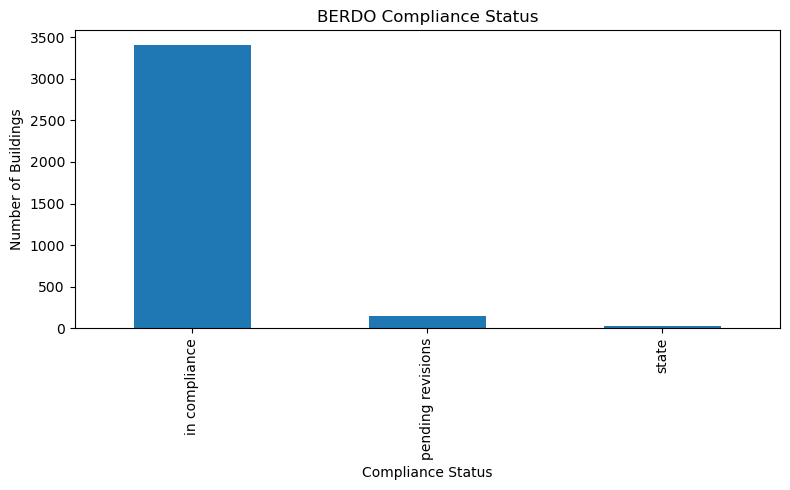

In [74]:
plt.figure(figsize=(8,5))
df["compliance_status"].value_counts().plot(kind="bar")
plt.title("BERDO Compliance Status")
plt.xlabel("Compliance Status")
plt.ylabel("Number of Buildings")
plt.tight_layout()
plt.show()

## Average EUI by Compliance

In [75]:
#average eui by compliance status
eui_by_compliance = (
    df.groupby("compliance_status")["site_eui"]
    .mean()
    .rename("average_eui")
    .reset_index()
    .sort_values(by="average_eui", ascending=False)
    .reset_index(drop = True)
)

eui_by_compliance.style.hide(axis = "index")

compliance_status,average_eui
state,92.032353
in compliance,76.413746
pending revisions,73.992000


### Observation

Buildings under state compliance exhibit the highest average EUI (approximately 92), indicating they are the most energy-intensive group. In contrast, buildings that are in compliance (approximately 76) and those with pending revisions (approximately 74) have lower and relatively similar energy use levels.

This pattern suggests that higher-energy buildings may require different compliance pathways or face greater challenges in meeting BERDO standards, while lower-energy buildings are more likely to achieve or approach compliance more easily.

<Axes: xlabel='compliance_status'>

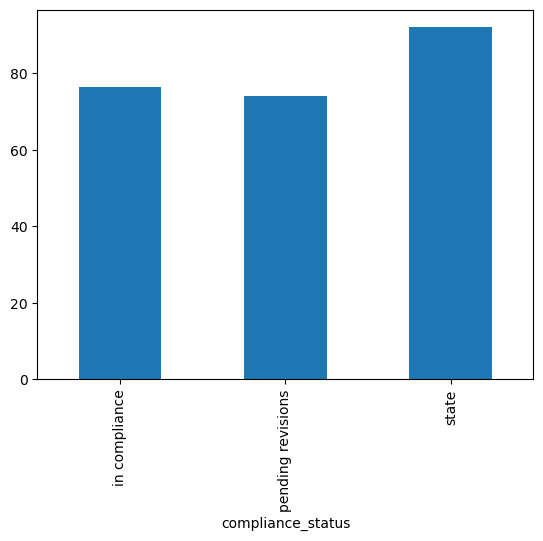

In [76]:
df[["gross_floor_area", "site_eui"]].corr()

df.groupby("compliance_status")["site_eui"].mean().plot(kind="bar")

## Conclusion

These findings suggest that BERDO compliance strategies should prioritize high-EUI buildings, 
particularly those under state pathways, where energy reduction opportunities are greatest.